# 重复执行

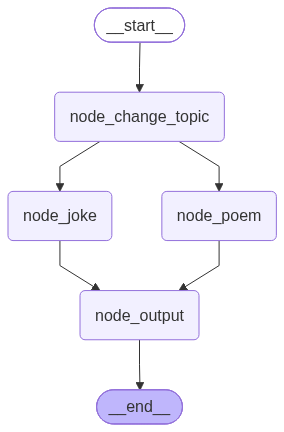

2026-08-02 17:03:04.318 | INFO     | __main__:node_change_topic:51 - topic_index:0
2026-08-02 17:03:04.320 | INFO     | __main__:node_joke:73 - node_joke正在执行
2026-08-02 17:03:04.322 | INFO     | __main__:node_poem:63 - node_poem正在执行
2026-08-02 17:03:11.989 | INFO     | __main__:node_output:84 - node_output正在执行


{'topic': '猫:布偶猫', 'poem': '《咏布偶猫》\n雪砌霜团玉作肤，银眸顾盼似星湖。\n仙姿偶落红尘里，懒卧花间戏鼠狐。\n\n注：本诗以“雪砌霜团”状布偶猫毛色之纯白蓬松，银眸如星湖暗合其蓝眼特征。后两句以“仙姿偶落”喻其气质出尘，尾句“懒卧戏鼠狐”既写实猫态，又暗含布偶猫温婉中藏机敏的灵动，赋予传统意象以现代宠物猫的鲜活气息。', 'joke': '好的，这里有几个关于布偶猫的笑话，请欣赏：\n\n**笑话一：关于摔跤**\n\n一只布偶猫正在沙发上优雅地踱步，忽然脚下一滑，四仰八叉地摔了下去。\n\n主人心疼地冲过去：“宝贝，没事吧？疼不疼？”\n\n布偶猫一脸淡定地躺在地上，幽幽地开口：“疼倒是不疼，就是我的‘仙气’差点摔漏了。你瞅瞅，这姿势，像不像一张价值十万的波斯地毯？”\n\n---\n\n**笑话二：关于抱抱**\n\n主人想抱起一只布偶猫，结果它死命地扒着地毯，像一块甩不掉的年糕。\n\n主人：“快松手，让我抱抱嘛！”\n\n布偶猫：“不松！你一抱我，我的毛就会静电爆炸，到时候整个屋子都是我的‘仙气飘飘’，你们凡人吸多了会醉的！”\n\n主人：“……那我吸一口，看看醉不醉？”\n\n布偶猫（立刻松爪，瘫软如泥）：“吸吧，吸完记得给我开个罐头，就当是‘精神损失费’。”\n\n---\n\n**笑话三：关于掉毛**\n\n客人来家里玩，看到布偶猫，惊叹：“哇，你这猫好漂亮，像个小仙女！”\n\n主人得意：“是啊，就是掉毛有点厉害。”\n\n客人不解：“掉毛能有多厉害？”\n\n布偶猫瞟了一眼客人，缓缓地从沙发上起身，抖了抖身子。只见一根根白色的猫毛在空气中缓缓飘落，像一场人工降雪。\n\n布偶猫对着目瞪口呆的客人，慵懒地说：“这位仙女，本仙是在给你表演‘天女散花’，收费可是按颗算的哦。”\n\n---\n\n**笑话四：关于智商**\n\n主人拿着一根逗猫棒，在布偶猫眼前晃来晃去。\n\n布偶猫全程瞪着一双湛蓝的大眼睛，纹丝不动，像个雕塑。\n\n主人：“你怎么不玩啊？是不是傻？”\n\n布偶猫（翻了个白眼）：“你那个动作，我都看穿三百年了。我是在思考，如何在你转身的时候，把你的手机从桌子上拍下去，并且装作是风吹的。”\n\n---\n\n希望这些笑话能让你会心一笑。', 'final_output': '关于猫:布偶猫的七言绝句:

In [2]:
import os
from typing import TypedDict

from IPython import display
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

load_dotenv(override=True)

# 获得大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


#1、声明状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str


# 1.1 输入状态
class InputState(TypedDict):
    topic: str


# 1.2 输出状态
class OutputState(TypedDict):
    final_output: str


topics = ["布偶猫", "狸花猫", "金渐层"]
topic_index = 0


# 2、定义节点
def node_change_topic(state: InputState) -> OverAllState:
    global topic_index
    logger.info("topic_index:{}", topic_index)
    sub_topic = topics[topic_index]
    topic_index += 1
    topic_index %= len(topics)

    return {
        "topic": f"{state["topic"]}:{sub_topic}"
    }


#2.1 同一个超步的位置 成功运行的节点
def node_poem(state: OverAllState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}主题的七言绝句")]).content
    return {
        "poem": poem
    }


#2.2 同一个超步的位置 运行失败的节点
def node_joke(state: OverAllState) -> OverAllState:
    logger.info("node_joke正在执行")
    topic = state["topic"]
    # time.sleep(5)
    # raise Exception("人为抛异常")
    joke = model.invoke([HumanMessage(f"写一首关于{topic}主题的笑话")]).content
    return {
        "joke": joke
    }


def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}的七言绝句:{poem}\n 笑话:{joke}\n"
    return {
        "final_output": final_output
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, OutputState=OutputState)

#3.1 添加节点
builder.add_node("node_change_topic", node_change_topic)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

#3.2 添加边
builder.add_edge(START, "node_change_topic")
builder.add_edge("node_change_topic", "node_poem")
builder.add_edge("node_change_topic", "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

# 4、添加检查地后端
DB_UEL = os.getenv("DB_URL")
with PostgresSaver.from_conn_string(DB_UEL) as checkpointer:
    #5. 第一次使用PostgresSaver作为检查点 需要调用方法 setup()
    #checkpointer.setup()
    graph = builder.compile(checkpointer=checkpointer)

    display.display(graph)

    config = {
        "configurable": {
            "thread_id": "chapter03-0801"
        }
    }

    res = graph.invoke({"topic": "猫"}, config=config)
    print(res)

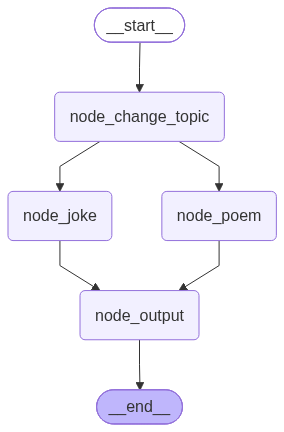

2026-08-02 17:05:37.863 | INFO     | __main__:node_change_topic:51 - topic_index:1
2026-08-02 17:05:37.865 | INFO     | __main__:node_joke:73 - node_joke正在执行
2026-08-02 17:05:37.868 | INFO     | __main__:node_poem:63 - node_poem正在执行
2026-08-02 17:05:47.620 | INFO     | __main__:node_output:84 - node_output正在执行


{'topic': '猫:狸花猫', 'poem': '《咏狸花猫》\n玄华织就虎纹斑，碧眼窥时月一弯。\n纵使身轻能搏兔，也随蝶影戏春闲。\n\n赏析：这首作品以狸花猫为题，通过“玄华织就虎纹斑”描绘其毛色如虎纹般华丽，“碧眼窥时月一弯”则生动刻画其眼眸如新月。后两句“纵使身轻能搏兔，也随蝶影戏春闲”巧妙对比，既赞美其捕猎的矫健身手，又展现其戏蝶时的闲适之态，形神兼备，意趣盎然。', 'joke': '这里有几个关于狸花猫的段子，请查收：\n\n**段子一：关于战斗力**\n家里养了只狸花猫，我总跟它说：“你瞅瞅隔壁的布偶猫，人家多温顺，再看看你，天天在家跟个二五八万似的。”\n狸花猫白了我一眼，没理我。\n直到有一天，邻居带着被狸花猫揍得满脸是伤的布偶猫来告状，我正想道歉，狸花猫却叼着一只比它脑袋还大的老鼠，大摇大摆地扔在邻居面前，然后一脸“看到没，这叫业绩，你那叫废物”的表情看着我。\n我默默把道歉的话咽了回去，突然觉得它揍布偶猫是有道理的——毕竟在猫界，业绩就是话语权。\n\n**段子二：关于“狸花”的由来**\n我问兽医：“大夫，我家这狸花猫怎么这么皮实，从六楼跳下去都没事？”\n兽医推了推眼镜，说：“你可能不知道，狸花猫的‘狸’字，在古代通‘离’。”\n我：“啥意思？”\n兽医：“意思是，它离地三尺，就自带降落伞；离你八丈远，就自带GPS。你们人类给它取名叫‘狸花’，其实是‘离花’——意思是，你家的花花草草，它都得给你薅离了。”\n我回头一看，阳台上的绿萝果然又被薅秃了。\n\n**段子三：关于抓老鼠**\n我花了三千块买了一只纯种英短，指望它能抓老鼠。\n结果老鼠在它面前溜达，它吓得钻进了沙发底下。\n没办法，我又把老家那只土生土长的狸花猫接来。\n狸花猫进家门第一件事，不是抓老鼠，而是先巡视了一圈，然后当着英短的面，把老鼠摁住，玩了一会儿，叼到我面前。\n它没吃，只是用爪子拍了拍英短的头，那眼神仿佛在说：\n“看好了，小老弟，这叫‘狸’物，不叫‘猫’物。你那个叫‘废’物。”\n\n**段子四：关于“中华气死猫”**\n我给我家狸花猫买了个自动喂食器，定时的。\n第一天，它盯着机器看了半天，然后一爪子把机器拍翻了，猫粮撒了一地。\n我以为它不会用，只好手动喂。\n后来我发现，它其实会用，但它就是不用。\n因为它觉得，**只有在我手忙脚乱给它铲屎、添粮、

In [3]:
with PostgresSaver.from_conn_string(DB_UEL) as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    display.display(graph)
    config = {
        "configurable": {
            "thread_id": "chapter03-0801"
        }
    }

    res = graph.invoke({"topic": "猫"}, config=config)
    print(res)

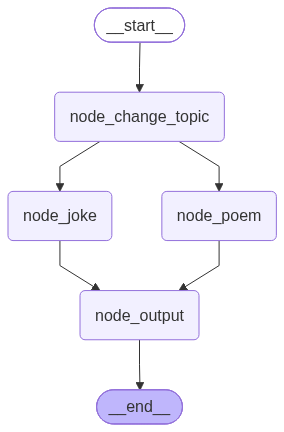

2026-08-02 17:06:02.542 | INFO     | __main__:node_change_topic:51 - topic_index:2
2026-08-02 17:06:02.544 | INFO     | __main__:node_joke:73 - node_joke正在执行
2026-08-02 17:06:02.547 | INFO     | __main__:node_poem:63 - node_poem正在执行
2026-08-02 17:06:12.136 | INFO     | __main__:node_output:84 - node_output正在执行


{'topic': '猫:金渐层', 'poem': '《咏金渐层》\n金裘玉爪步生烟，碧眼窥人欲破禅。\n偶过花荫衔蝶影，卧听风语不知年。\n\n注：本诗以金渐层猫为吟咏对象，通过“金裘玉爪”状其毛色形态，“碧眼窥禅”写其灵性神态。后两句以“衔蝶”“听风”二事，展现金渐层优雅慵懒之姿，尾句“不知年”更添超然物外之趣。全诗紧扣金渐层特征，虚实相生，意境悠远。', 'joke': '《一只金渐层的自我修养》\n\n我，金渐层，江湖人称“行走的金币”。今天要曝光我的人类——她以为她驯养了我，其实我驯养了她。\n\n早晨六点，她还在梦里数钱，我跳上枕头，用肉垫拍她的脸。她惊醒：“宝宝饿了吗？”我扭头就走——这是我的策略，叫“欲擒故纵”。她果然追到厨房，开了一罐金枪鱼罐头。\n\n呵，人类。以为我是为了那口吃的？我只是喜欢看她穿着睡衣、顶着鸡窝头，为朕鞍前马后的样子。\n\n不过她最近有“造反”的苗头。我躺在沙发上露出金色肚皮，她居然说：“你看看你，像个掉地上的发面饼。”我立刻咬她拖鞋——这是“教做人”环节。她居然大笑：“咬吧咬吧，反正该买鞋了。”\n\n更过分的是，她给我买了个“自动逗猫棒”。这让我怎么演“扑了半天抓不到”的苦情戏？我决定罢工，趴在那机器面前，用一种“你在教朕做事？”的眼神盯着她。她居然说：“哎呀好高级，AI猫都这么拽吗？”\n\n晚上，我正专心舔毛，她突然举着手机说：“看！专家说金渐层爱掉毛，你们是行走的蒲公英。”我瞪她，然后慢悠悠走到她刚洗的白色衬衫上，打了个滚。\n\n看着她尖叫，我无比满足。但最让我破防的——是她说：“等你老了，毛变白了，就是银渐层，还能再涨一波身价。”\n\n我当场石化。原来在她眼里，我不是猫，是理财产品！\n\n那天夜里，我做了个决定：她开会时，我跳上电脑，在键盘上按出一行字：“老板，这个月的罐头是30%的提成。”\n\n她吓得当场关掉摄像头。我在旁边舔爪——跟我玩金融？我行走江湖靠的是黄金比例毛色，以及对人类弱点的精准拿捏。\n\n后来她再也没提过“理财产品”四个字。只是那天夜里，我听到她梦呓：“猫主子，我错了。”\n\n这就是我们金渐层——不是我们在讨好人类，是世界需要我们的毛色来治愈。至于身价？那是我用肉垫拍脸、用尾巴扫键盘挣来的演出费，她最多算我的经纪人。\n\n而她，至今还在朋友圈炫耀：“我家猫会倒立接零食。”\n\n

In [4]:
with PostgresSaver.from_conn_string(DB_UEL) as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    display.display(graph)
    config = {
        "configurable": {
            "thread_id": "chapter03-0801"
        }
    }

    res = graph.invoke({"topic": "猫"}, config=config)
    print(res)

In [6]:
# 获取
with PostgresSaver.from_conn_string(DB_UEL) as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    config = {
        "configurable": {
            "thread_id": "chapter03-0801"
        }
    }
    # 获取了检查点
    history_checkpoints = list(graph.get_state_history(config=config))

    newCheckPoint = None
    for checkpoint in history_checkpoints:
        # 找到next 为 节点poem和joke的前置节点
        if checkpoint.next == ('node_poem', 'node_joke',):
            newCheckPoint = checkpoint
            break
    # print(newCheckPoint)

    # 实现replay 的效果，状态填写None， config填写为之前某个检查点的config
    res = graph.invoke(None, config = newCheckPoint.config)
    print(res)

2026-08-02 18:38:39.146 | INFO     | __main__:node_joke:73 - node_joke正在执行
2026-08-02 18:38:39.148 | INFO     | __main__:node_poem:63 - node_poem正在执行
2026-08-02 18:38:42.735 | INFO     | __main__:node_output:84 - node_output正在执行


{'topic': '猫:金渐层', 'poem': '《咏金渐层》\n金鳞玉爪步生烟，碧眼窥人若洞天。\n捕影何须窥月下，衔鱼自可傲云巅。\n\n赏析：这首作品以金渐层猫为咏诵对象，通过“金鳞玉爪”展现其毛色之美，“碧眼窥人”刻画其灵动神韵。后两句运用“捕影衔鱼”的意象，暗喻其敏捷天性，尾句“傲云巅”更以夸张手法，将猫的矜贵气质升华至云端，全诗虚实相生，形神兼备。', 'joke': '一只金渐层走进咖啡店，跳上吧台，用爪子推了推菜单。\n\n店员：“您好，请问喝点什么？”\n金渐层：“喵。”（指了指“金汤力”）\n店员：“好的，一杯金汤力。”\n金渐层：“喵！”（又指了指“金骏眉”）\n店员：“……您是要两杯？”\n金渐层：“喵！！”（疯狂摇头，把整个脸埋进菜单里）\n\n店员终于懂了：“哦——您是要‘金渐层’本层？”\n金渐层满意地点头，然后瘫成一滩融化的黄油。\n\n店员小声嘀咕：“史上第一只会点单的猫，就是菜单翻得太快，全是毛。”\n\n（金渐层排队买单时，掏出一把金色毛球当硬币）\n“喵，不用找了，剩下的拿去做‘金粉世家’。”', 'final_output': '关于猫:金渐层的七言绝句:《咏金渐层》\n金鳞玉爪步生烟，碧眼窥人若洞天。\n捕影何须窥月下，衔鱼自可傲云巅。\n\n赏析：这首作品以金渐层猫为咏诵对象，通过“金鳞玉爪”展现其毛色之美，“碧眼窥人”刻画其灵动神韵。后两句运用“捕影衔鱼”的意象，暗喻其敏捷天性，尾句“傲云巅”更以夸张手法，将猫的矜贵气质升华至云端，全诗虚实相生，形神兼备。\n 笑话:一只金渐层走进咖啡店，跳上吧台，用爪子推了推菜单。\n\n店员：“您好，请问喝点什么？”\n金渐层：“喵。”（指了指“金汤力”）\n店员：“好的，一杯金汤力。”\n金渐层：“喵！”（又指了指“金骏眉”）\n店员：“……您是要两杯？”\n金渐层：“喵！！”（疯狂摇头，把整个脸埋进菜单里）\n\n店员终于懂了：“哦——您是要‘金渐层’本层？”\n金渐层满意地点头，然后瘫成一滩融化的黄油。\n\n店员小声嘀咕：“史上第一只会点单的猫，就是菜单翻得太快，全是毛。”\n\n（金渐层排队买单时，掏出一把金色毛球当硬币）\n“喵，不用找了，剩下的拿去做‘金粉世家’。”\n'}
